In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/tabular/heart_disease_uci.csv")

In [3]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
df.shape

(920, 16)

In [5]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')

In [6]:
df["num"].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [7]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [8]:
df.dtypes

id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 156.4+ KB


In [10]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [11]:
df.describe(include="object")

C:\Users\Hp\AppData\Local\Temp\ipykernel_20056\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,sex,dataset,cp,fbs,restecg,exang,slope,thal
count,920,920,920,830,918,865,611,434
unique,2,4,4,2,3,2,3,3
top,Male,Cleveland,asymptomatic,False,normal,False,flat,normal
freq,726,304,496,692,551,528,345,196


In [12]:
clean_df = df.copy()

In [13]:
clean_df = clean_df.drop(columns=["id", "dataset", "ca", "thal"])

In [14]:
clean_df["target"] = (clean_df["num"] > 0).astype(int)

In [15]:
clean_df = clean_df.drop(columns=["num"])

In [16]:
clean_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,target
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0


In [17]:
clean_df.shape

(920, 12)

In [18]:
clean_df["target"].value_counts()

target
1    509
0    411
Name: count, dtype: int64

In [19]:
clean_df.isnull().sum()

age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
target        0
dtype: int64

In [20]:
numerical_columns = ["trestbps", "chol", "thalch", "oldpeak"]

for column in numerical_columns:
    clean_df[column] = clean_df[column].fillna(clean_df[column].median())

In [21]:
categorical_columns = ["fbs", "restecg", "exang", "slope"]

for column in categorical_columns:
    clean_df[column] = clean_df[column].fillna(clean_df[column].mode()[0])

In [22]:
clean_df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
target      0
dtype: int64

In [23]:
clean_df["sex"].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

In [24]:
clean_df["cp"].value_counts()

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

In [25]:
clean_df["restecg"].value_counts()

restecg
normal              553
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64

In [26]:
clean_df["slope"].value_counts()

slope
flat           654
upsloping      203
downsloping     63
Name: count, dtype: int64

In [27]:
model_df = df.drop(columns=["id", "dataset", "ca", "thal"])

In [28]:
y = (model_df["num"] > 0).astype(int)

In [29]:
X = model_df.drop(columns=["num"])

In [30]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (920, 11)
y shape: (920,)


In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [33]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 736
Testing samples: 184


In [34]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
num
1    407
0    329
Name: count, dtype: int64

Testing target distribution:
num
1    102
0     82
Name: count, dtype: int64


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Preprocessing imports successful!")

Preprocessing imports successful!


In [36]:
# Create a copy of the original dataset
model_df = df.drop(columns=["id", "dataset", "ca", "thal"])

# Create the target variable
# 0 = No heart disease
# 1 = Heart disease
y = (model_df["num"] > 0).astype(int)

# Create the input features
X = model_df.drop(columns=["num"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (920, 11)
y shape: (920,)


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (736, 11)
Testing data: (184, 11)


In [38]:
# Numerical columns
numerical_columns = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak"
]

# Categorical columns
categorical_columns = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope"
]

print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)

Numerical columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']


In [39]:
# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both pipelines
preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [40]:
from sklearn.linear_model import LogisticRegression

# Create the complete machine learning pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

print("Model pipeline created successfully!")

Model pipeline created successfully!


In [41]:
# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [42]:
# Make predictions on the test data
y_pred = model.predict(X_test)

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 184


In [43]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", round(accuracy * 100, 2))

Model Accuracy: 0.8152173913043478
Model Accuracy (%): 81.52


In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

Precision: 0.8036
Recall: 0.8824
F1-score: 0.8411


Confusion Matrix:
[[60 22]
 [12 90]]


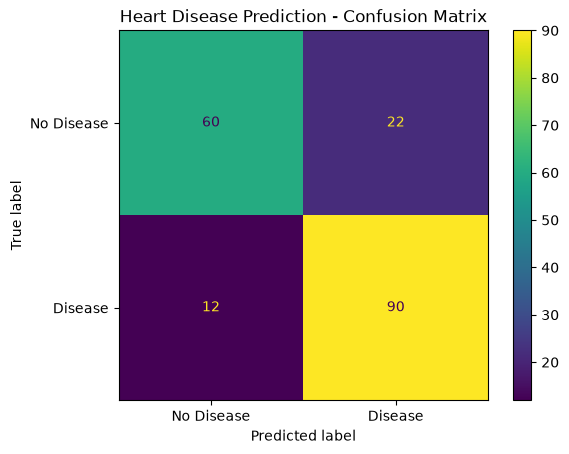

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()
plt.title("Heart Disease Prediction - Confusion Matrix")
plt.show()

In [46]:
from sklearn.metrics import roc_auc_score

# Get probability of the positive class (heart disease)
y_probability = model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.9044


In [47]:
import joblib

# Save the complete pipeline
joblib.dump(model, "../models/heart_disease_model.pkl")

print("Heart disease model saved successfully!")

Heart disease model saved successfully!


In [48]:
import joblib

# Load the saved model
loaded_model = joblib.load("../models/heart_disease_model.pkl")

# Test the loaded model
test_predictions = loaded_model.predict(X_test[:5])

print("Saved model loaded successfully!")
print("Test predictions:", test_predictions)

Saved model loaded successfully!
Test predictions: [0 1 1 1 1]
